In [76]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [77]:
def ordered_dithering(image: Image.Image, matrix: np.ndarray) -> Image.Image:
    img = image.convert('L')
    arr = np.array(img, dtype=np.uint8)

    n = matrix.shape[0]
    threshold_map = (matrix + 0.5) * (255 / (n * n))

    result = np.zeros_like(arr)

    for y in range(arr.shape[0]):
        for x in range(arr.shape[1]):
            i, j = y % n, x % n
            threshold = threshold_map[i, j]
            result[y, x] = 255 if arr[y, x] > threshold else 0

    return Image.fromarray(result.astype(np.uint8))

In [78]:
input_path = "input.jpg"
original = Image.open(input_path)

In [79]:
def image_show(image, dithered, title):
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image.convert('L'), cmap='gray')
    plt.title("Original (Grayscale)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(dithered, cmap='gray')
    plt.title(title)
    plt.axis('off')

    plt.show()

### Алгоритм розсіювання помилок Флойда-Стейнберга

In [80]:
G_1 = 1/16 * np.array([
    [ 0, 0, 0 ],
    [ 0, 0, 7 ],
    [ 3, 5, 1 ]
], dtype=np.uint8)


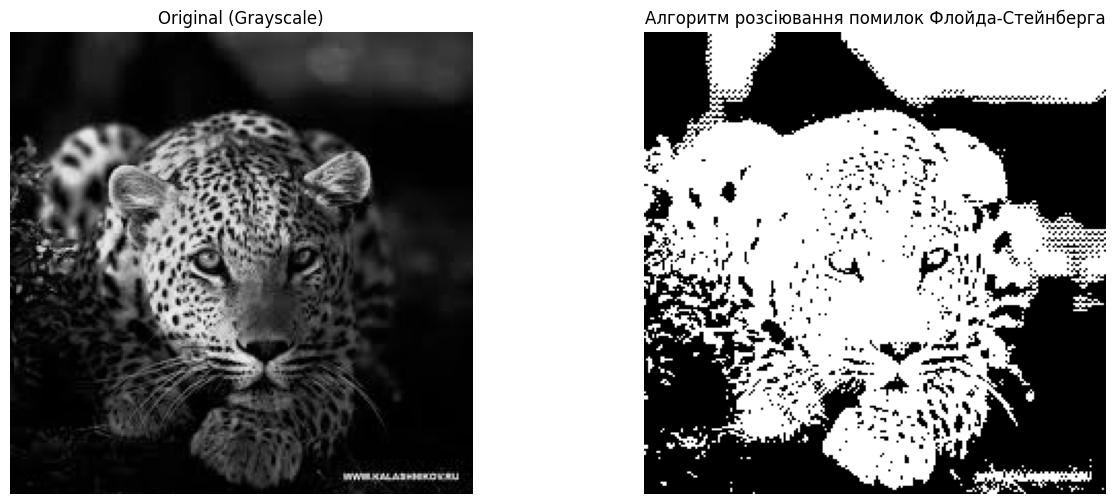

In [81]:
dithered_1 = ordered_dithering(original, G_1)

image_show(original, dithered_1, 'Алгоритм розсіювання помилок Флойда-Стейнберга')

### Алгоритм Джарвіса–Джудіса–Нінке

In [82]:
G_2 = 1/48 * np.array([
    [ 0, 0, 0, 7, 5 ],
    [ 3, 5, 7, 5, 3 ],
    [ 1, 3, 5, 3, 1 ]
], dtype=np.uint8)


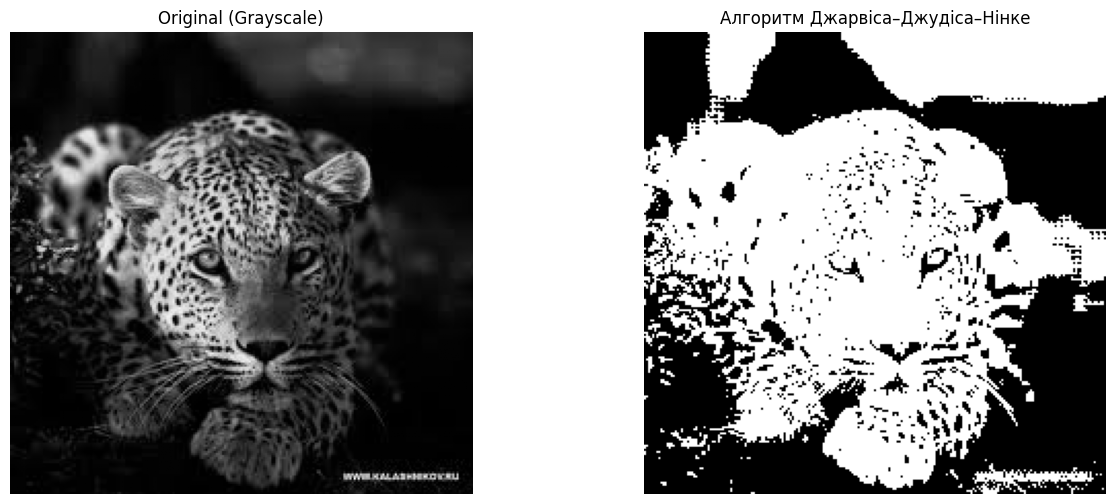

In [83]:
dithered_2 = ordered_dithering(original, G_2)

image_show(original, dithered_2, 'Алгоритм Джарвіса–Джудіса–Нінке')

### Алгоритм Пітера Штуки

In [84]:
G_3 = 1/42 * np.array([
    [ 0, 0, 0, 8, 4 ],
    [ 2, 4, 8, 4, 2 ],
    [ 1, 2, 4, 2, 1 ]
], dtype=np.uint8)


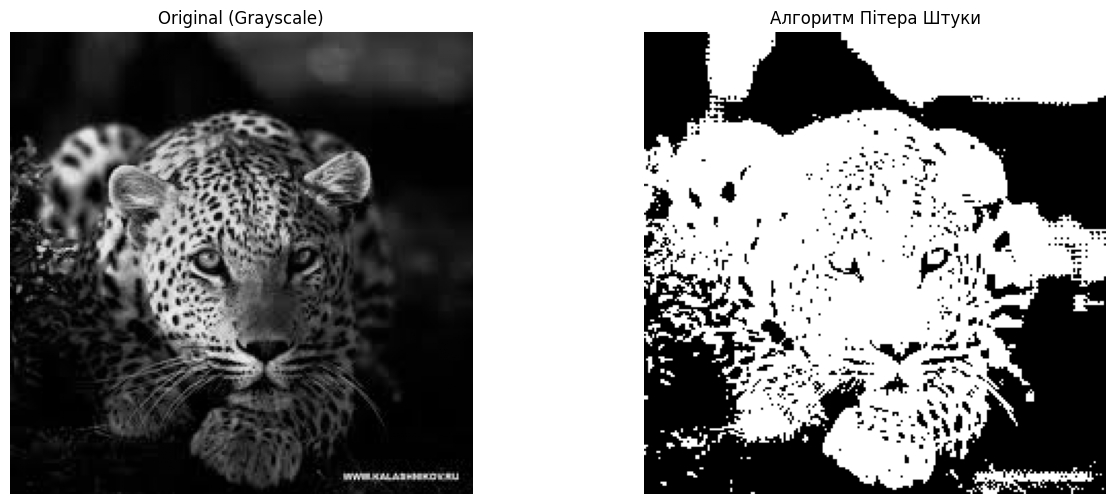

In [85]:
dithered_3 = ordered_dithering(original, G_3)

image_show(original, dithered_3, 'Алгоритм Пітера Штуки')

### Алгоритм Аткінсона

In [86]:
G_4 = 1/8 * np.array([
    [ 0, 0, 1, 1 ],
    [ 1, 1, 1, 0 ],
    [ 0, 1, 0, 0 ]
], dtype=np.uint8)


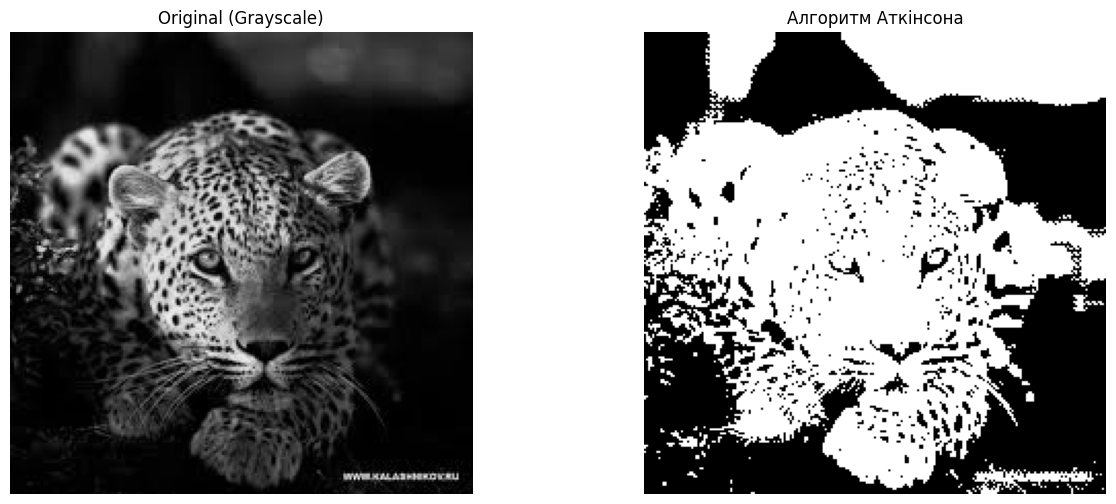

In [87]:
dithered_4 = ordered_dithering(original, G_4)

image_show(original, dithered_4, 'Алгоритм Аткінсона')

### Алгоритм Беркеса

In [88]:
G_5 = 1/32 * np.array([
    [ 0, 0, 0, 8, 4 ],
    [ 2, 4, 8, 4, 2 ]
], dtype=np.uint8)


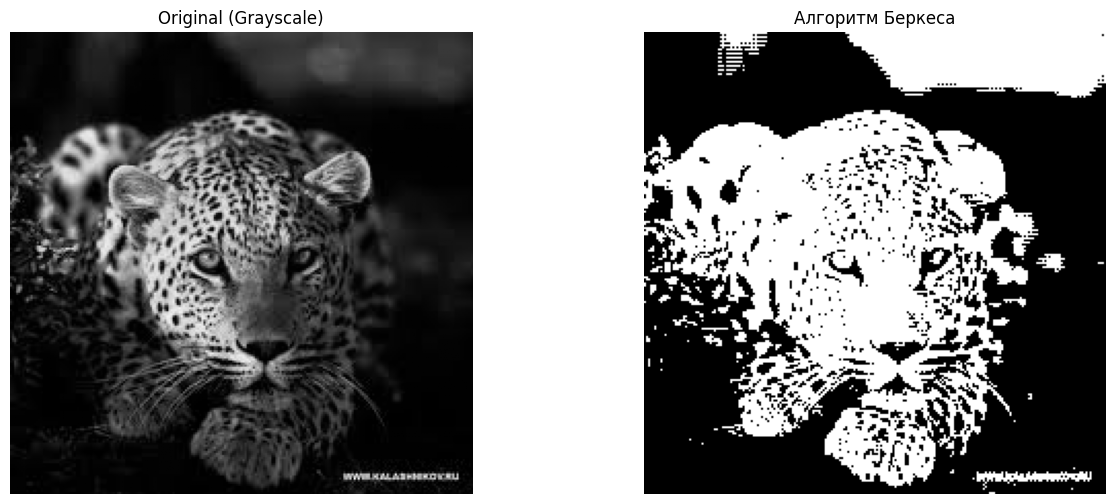

In [89]:
dithered_5 = ordered_dithering(original, G_5)

image_show(original, dithered_5, 'Алгоритм Беркеса')

### Алгоритм Сієрри

In [90]:
G_6 = 1/32 * np.array([
    [ 0, 0, 0, 5, 3 ],
    [ 2, 4, 5, 4, 2 ],
    [ 0, 2, 3, 2, 0 ]
], dtype=np.uint8)


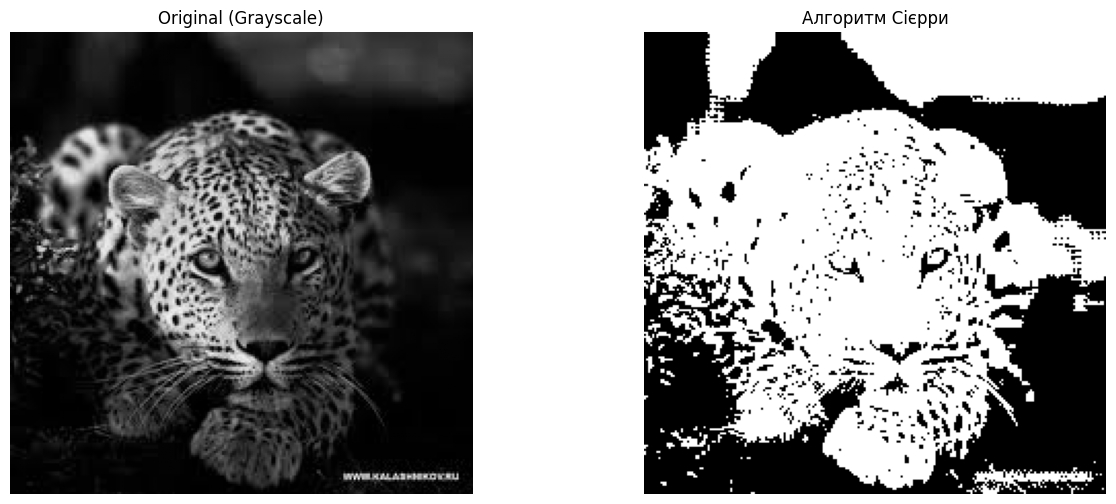

In [91]:
dithered_6 = ordered_dithering(original, G_6)

image_show(original, dithered_6, 'Алгоритм Сієрри')

### Алгоритм Байєра

In [92]:
M_4 = np.array([
    [ 0,  8,  2, 10],
    [12,  4, 14,  6],
    [ 3, 11,  1,  9],
    [15,  7, 13,  5]
], dtype=np.uint8)

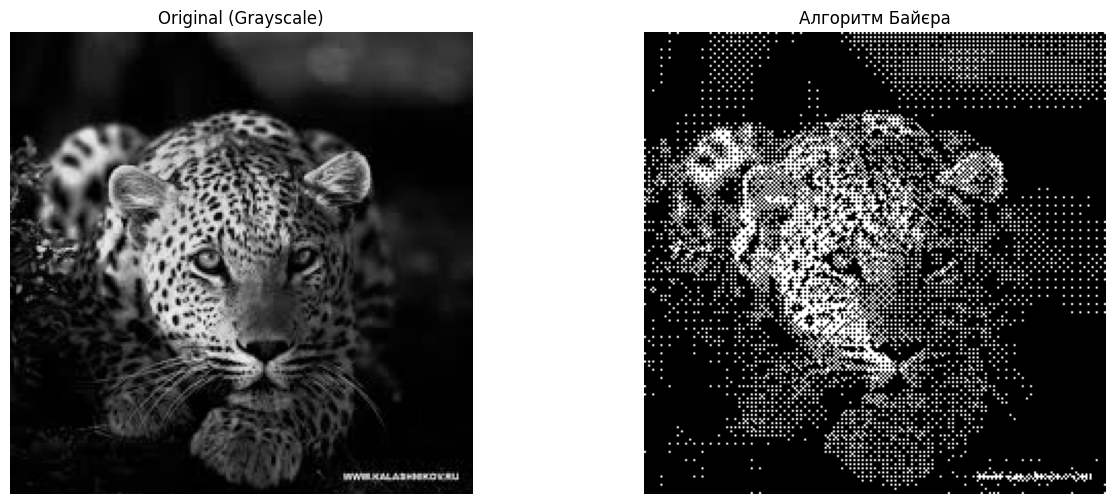

In [93]:
dithered_7 = ordered_dithering(original, M_4)

image_show(original, dithered_7, 'Алгоритм Байєра')

### Гауссовий випадковий дизеринг

In [94]:
def gaussian_dithering(image: Image.Image, mean: float = 0, stddev: float = 20) -> Image.Image:
    img = image.convert('L')
    arr = np.array(img, dtype=np.float32)

    noise = np.random.normal(loc=mean, scale=stddev, size=arr.shape)
    noisy = arr + noise

    noisy = np.clip(noisy, 0, 255)

    result = (noisy > 127).astype(np.uint8) * 255

    return Image.fromarray(result)

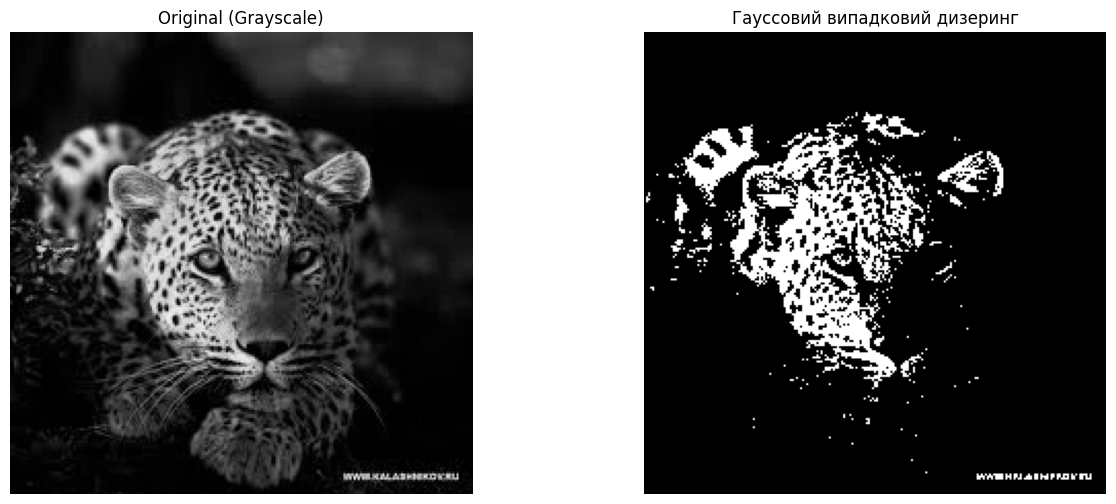

In [95]:
gaussian_dithered = gaussian_dithering(original, mean=0, stddev=20)

image_show(original, gaussian_dithered, 'Гауссовий випадковий дизеринг')